In [1]:
library(torch)
library(luz)
#library(lecospectR)

In [2]:
source("./Functions/lecospectR.R")

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: compiler

Loading required package: raster

Loading required package: sp


Attaching package: ‘raster’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: hsdar

Loading required package: rgdal

Please note that rgdal will be retired during October 2023,
plan transition to sf/stars/terra functions using GDAL and PROJ
at your earliest convenience.
See https://r-spatial

In [3]:
net <- nn_module(
    "jigsaw",
     initialize = function(num_components = NUM_VARS, num_levels = 8) {
      self$internal_dimension <- 512
      



      #C block
      self$net <- nn_sequential(
        nn_flatten(start_dim = 2,end_dim = -1),
        nn_linear(
          in_features = 95,
          out_features = self$internal_dimension
        ),
        nn_relu(),
        nn_dropout(p = 0.3),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        nn_relu(),
             nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        nn_relu(),
             nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
            nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
            nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
            nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
            nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
                nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
                nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
                nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
                nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
                nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
                nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
                nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
                nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.3),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = 8
        )
      )
  },

  forward = function(x) {
    return(self$net(x))
  }
)

In [4]:
add_channel_dim <- function(img) {
   x <- img$unsqueeze(1)
   return(torch_transpose(x, 1,2))
}

In [5]:
create_variable_names <- function(start, stop){
    names <- c()
    for(i in start:stop){
        names <- append(
            names, 
            paste0("X", i))
    }

    return(names)
}

In [6]:
independent_variables <- create_variable_names(400L, 999L)

dependent_variable <- "FncGrp1" 
NUM_VARS <- length(independent_variables)
print(length(independent_variables))

[1] 600


In [7]:
# define the dataset
data_df <- read.csv(
    file = "Data/Ground_Validation/PFT_image_spectra/PFT_Image_SpectralLib_Clean.csv"
    )


In [8]:

lecospec_dataset <- torch::dataset(
    name = "lecospec_image",
    initialize = function(df, transform = function(x){x}) {
        self$x <- as.matrix(
            #cbind(
            #    df[, independent_variables], 
                get_vegetation_indices(df = df, ml_model = NULL) %>%
                    clip_outliers()
            #)
        )
        
        self$y <- torch_tensor(
            as.matrix(
                as.integer(
                    as.factor(
                        df[, dependent_variable]
                        )
                    )
                )
            )
        self$transform <- transform
    },

    .getitem = function(i) {
        list(
            x = self$transform(torch_flatten(self$x[i,])),
            y = torch_flatten(self$y[i])$squeeze()
        )
    },

    .length = function() {
        self$y$size()[[1]]
    }
)

In [9]:
head(data_df)

,X,UID,ScanNum,sample_name,PFT,FncGrp1,Site,X398,X399,X400,⋯,X990,X991,X992,X993,X994,X995,X996,X997,X998,X999
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,BisonGulchPFTsBetula1,1,spec_1,Betula,ShrubDecid,BisonGulch,0.05814769,0.05926529,0.06028869,⋯,0.6815182,0.6811660,0.6890470,0.7040298,0.7249807,0.7507566,0.7801884,0.8121027,0.8453261,0.8786852
2,2,BisonGulchPFTsBetula1,1,spec_2,Betula,ShrubDecid,BisonGulch,0.04456014,0.04778814,0.05079318,⋯,0.6706666,0.6683159,0.6786394,0.7000307,0.7308801,0.7695067,0.8140391,0.8625739,0.9132079,0.9640378
3,3,BisonGulchPFTsBetula1,1,spec_3,Betula,ShrubDecid,BisonGulch,0.03929324,0.04265593,0.04557066,⋯,0.5152525,0.5091915,0.5178217,0.5395294,0.5726982,0.6156166,0.6663192,0.7227978,0.7830447,0.8450520
4,4,BisonGulchPFTsBetula1,1,spec_4,Betula,ShrubDecid,BisonGulch,0.13230228,0.11122692,0.09129034,⋯,0.5120581,0.5113880,0.5348292,0.5745538,0.6227243,0.6723311,0.7185860,0.7570701,0.7833644,0.7930498
5,5,BisonGulchPFTsBetula1,1,spec_5,Betula,ShrubDecid,BisonGulch,0.05211388,0.05565497,0.05878525,⋯,0.6863419,0.6680365,0.6509006,0.6344450,0.6181806,0.6017555,0.5851848,0.5685449,0.5519121,0.5353626
6,6,BisonGulchPFTsBetula1,1,spec_6,Betula,ShrubDecid,BisonGulch,0.06955397,0.06788242,0.06631141,⋯,0.7354495,0.7371508,0.7445194,0.7567953,0.7732173,0.7930235,0.8154512,0.8397375,0.8651196,0.8908347


In [10]:
num_per_pft <- 300
train_test_data <- create_patch_balanced_sample(
    data_df,
    test_count = 20,
    train_count = NULL,
    verbose = FALSE
    )

split_2_train <- create_patch_balanced_sample(
    train_test_data$remainder,
    test_count = num_per_pft,
    train_count = 2000,
    verbose = FALSE
    )

In [11]:
print(names(split_2_train))

[1] "selection"         "remainder"         "samples_per_patch"
[4] "samples_per_class"


In [12]:
print(split_2_train$selection)

      X                   UID ScanNum sample_name    PFT        FncGrp1
23   23 BisonGulchPFTsBetula1       1     spec_23 Betula     ShrubDecid
4     4 BisonGulchPFTsBetula1       1      spec_4 Betula     ShrubDecid
13   13 BisonGulchPFTsBetula1       1     spec_13 Betula     ShrubDecid
10   10 BisonGulchPFTsBetula1       1     spec_10 Betula     ShrubDecid
6     6 BisonGulchPFTsBetula1       1      spec_6 Betula     ShrubDecid
25   25 BisonGulchPFTsBetula1       1     spec_25 Betula     ShrubDecid
21   21 BisonGulchPFTsBetula1       1     spec_21 Betula     ShrubDecid
17   17 BisonGulchPFTsBetula1       1     spec_17 Betula     ShrubDecid
5     5 BisonGulchPFTsBetula1       1      spec_5 Betula     ShrubDecid
7     7 BisonGulchPFTsBetula1       1      spec_7 Betula     ShrubDecid
19   19 BisonGulchPFTsBetula1       1     spec_19 Betula     ShrubDecid
3     3 BisonGulchPFTsBetula1       1      spec_3 Betula     ShrubDecid
37   37 BisonGulchPFTsBetula2       2     spec_12 Betula     Shr

In [13]:
train_indices <- sample(1:nrow(data_df), 250)
train_ds <- lecospec_dataset(
    split_2_train$selection,
    transform = add_channel_dim
    )
valid_ds <- lecospec_dataset(
    train_test_data$selection, 
    transform = add_channel_dim
    )

length(train_ds)
length(valid_ds)

[1] 2222

[1] 160

In [14]:
# create a dataloader
test_dl <- torch::dataloader(
    valid_ds,
    batch_size = 80,
    shuffle = FALSE
)

train_dl <- torch::dataloader(
    train_ds,
    batch_size = 240,
    shuffle = TRUE
)

In [15]:
batch <- dataloader_make_iter(train_dl) %>% dataloader_next()
print(dim(batch$x))
print(dim(batch$y))

[1] 240 695   1
[1] 240


In [16]:
print(batch$x$shape)

[1] 240 695   1


In [17]:
print(batch$y$shape)

[1] 240


In [18]:
model <- net()
model(batch$x)


torch_tensor
0.01 *
 4.7175 -0.1385 -1.2478  2.9238 -2.5007  4.1934  4.3112  0.3087
  4.7239 -4.4875 -1.0100  1.6260 -3.5689  4.4764  4.8929  0.2840
  6.0822 -4.0793 -1.8690  3.8304 -3.1500  4.6274  4.9811 -1.2124
  3.2959 -5.8433  0.1318  0.6041 -3.3718  5.1632  3.7092 -0.7909
  4.7262 -1.6641 -1.4738  2.5887 -3.1006  5.7101  2.7395  0.6354
  6.9366 -6.7397 -0.6736  3.2589 -4.0466  2.9076  5.1391 -0.1812
  4.1100 -2.0571 -1.2277  1.8680 -2.0511  5.6353  4.7984 -0.9338
  4.9238 -3.5950 -2.1819  4.2523 -2.6931  4.5033  5.0210  0.6369
  3.8838 -1.8786 -3.2189  3.8171 -0.2950  4.3082  4.3359 -0.4958
  5.1456 -4.0928 -1.1767  3.2631 -2.5149  4.8659  5.2547 -0.4335
  4.6592 -4.9002 -2.9527  2.6746 -1.6217  3.5559  5.4782 -1.1607
  3.1127 -2.0610 -1.3133  1.7367  0.0170  4.7571  2.0442  0.3801
  4.6990 -3.2423 -0.0633 -0.0946 -2.7078  5.5301  1.9226  0.0925
  3.7093 -3.9940  0.1774  4.2285 -2.2527  3.2385  2.7295  0.5185
  2.8001 -4.3803 -2.0244  1.7523 -0.8111  5.1417  3.9442 -0.6831
  4.02

In [19]:
batch$y

torch_tensor
 3
 4
 2
 2
 3
 1
 2
 4
 2
 4
 2
 5
 1
 7
 2
 7
 4
 5
 3
 3
 2
 6
 4
 2
 7
 3
 1
 2
 1
 5
... [the output was truncated (use n=-1 to disable)]
[ CPULongType{240} ]

In [20]:
print_callback <- luz_callback(
  name = "print_callback",
  initialize = function(message) {
    self$message <- message
  },
  on_train_batch_end = function() {
    cat("Iteration ", ctx$iter, "\n")
  },
  on_epoch_end = function() {
    cat(self$message, "\n")
  }
)

In [21]:
net_fitted <- net %>%
  setup(
    loss = nn_cross_entropy_loss(),
    optimizer = optim_adam,
    metrics = list(
      luz_metric_accuracy()
    )
  ) %>%
  set_opt_hparams(lr = 0.001) %>% 
  fit(
    train_dl, 
    epochs = 1000, 
    valid_data = test_dl,
    callbacks = list(
      print_callback("Training Complete")
    )
    )

Iteration  1 
Iteration  2 
Iteration  3 
Iteration  4 
Iteration  5 
Iteration  6 
Iteration  7 
Iteration  8 
Iteration  9 
Iteration  10 
Training Complete 
Iteration  1 
Iteration  2 
Iteration  3 
Iteration  4 
Iteration  5 
Iteration  6 
Iteration  7 
Iteration  8 
Iteration  9 
Iteration  10 
Training Complete 
Iteration  1 
Iteration  2 
Iteration  3 
Iteration  4 
Iteration  5 
Iteration  6 
Iteration  7 
Iteration  8 
Iteration  9 
Iteration  10 
Training Complete 
Iteration  1 
Iteration  2 
Iteration  3 
Iteration  4 
Iteration  5 
Iteration  6 
Iteration  7 
Iteration  8 
Iteration  9 
Iteration  10 
Training Complete 
Iteration  1 
Iteration  2 
Iteration  3 
Iteration  4 
Iteration  5 
Iteration  6 
Iteration  7 
Iteration  8 
Iteration  9 
Iteration  10 
Training Complete 
Iteration  1 
Iteration  2 
Iteration  3 
Iteration  4 
Iteration  5 
Iteration  6 
Iteration  7 
Iteration  8 
Iteration  9 
Iteration  10 
Training Complete 
Iteration  1 
Iteration  2 
Iteration  3

In [22]:
net_fitted

A `luz_module_fitted`
── Time ────────────────────────────────────────────────────────────────────────
• Total time: 1h 21m 53.7s
• Avg time per training epoch: 9.5s

── Results ─────────────────────────────────────────────────────────────────────
Metrics observed in the last epoch.

ℹ Training:
loss: 1.4109
acc: 0.3933

── Model ───────────────────────────────────────────────────────────────────────
An `nn_module` containing 3,774,984 parameters.

── Modules ─────────────────────────────────────────────────────────────────────
• net: <nn_sequential> #3,774,984 parameters

In [23]:
predict(net_fitted,newdata = batch$x)

torch_tensor
 0.9212 -1.6343  0.7694  0.7074 -1.4398 -0.2591 -3.8772 -0.4638
 2.5616 -3.0778  2.4289  3.5379 -4.5464 -1.2201 -9.8402 -4.0075
 0.9707 -1.0510  0.8871  0.9541 -1.5365 -0.3275 -4.1660 -0.7601
 1.9880 -2.4426  1.9619  2.7106 -3.5156 -0.9781 -7.7659 -2.9481
 0.8352 -1.3511  0.6906  0.7125 -1.2908 -0.3711 -3.3585 -0.4695
 2.5189 -3.0301  2.3941  3.4764 -4.4699 -1.2020 -9.6859 -3.9286
 1.5537 -1.9321  1.5871  2.0624 -2.7145 -0.7883 -6.1674 -2.1242
 2.5720 -3.0893  2.4373  3.5528 -4.5649 -1.2245 -9.8775 -4.0266
 1.4460 -1.8005  1.4923  1.8976 -2.5133 -0.7376 -5.7717 -1.9159
 2.5676 -3.0844  2.4337  3.5465 -4.5571 -1.2227 -9.8617 -4.0185
 2.3690 -2.8632  2.2717  3.2599 -4.2001 -1.1385 -9.1440 -3.6507
 0.9786 -1.0775  0.9021  0.9746 -1.5532 -0.3399 -4.1852 -0.7830
 1.0852 -7.1539  1.8824 -0.9297 -1.2002  0.4129 -7.6667 -0.3987
 0.8273 -0.4498  0.6109  0.5978 -1.2666 -0.1070 -3.8496 -0.4197
 1.4317 -1.7821  1.4793  1.8752 -2.4862 -0.7303 -5.7189 -1.8876
-0.5208  1.3698 -2.3290 -1.

## Next

Need to define the correct nueral net architecture, and then the training loop should work as intended.  This is likely some kind of U-Net from a paper.  

Just a matter of finding the correct one and plugging the layers into the model above.  

Hopefully that works directly

In [24]:
preds <- predict(net_fitted, test_dl)

torch_tensor
Columns 1 to 6 7.0673e-01  1.1122e-02  3.9746e-01  3.4953e-01 -1.0842e+00  1.3918e-02
-3.6740e-01  1.3289e+00 -2.1262e+00 -1.5980e+00 -5.1614e-01  3.4320e-01
 1.4813e+00 -1.8435e+00  1.5233e+00  1.9515e+00 -2.5790e+00 -7.5444e-01
 1.3952e+00 -1.7331e+00  1.4448e+00  1.8169e+00 -2.4162e+00 -7.1128e-01
 1.9702e+00 -2.4228e+00  1.9475e+00  2.6850e+00 -3.4838e+00 -9.7057e-01
 2.1983e+00 -2.6750e+00  2.1327e+00  3.0135e+00 -3.8931e+00 -1.0665e+00
 2.3654e+00 -2.8590e+00  2.2688e+00  3.2548e+00 -4.1937e+00 -1.1370e+00
 1.7852e+00 -2.2102e+00  1.7909e+00  2.4130e+00 -3.1460e+00 -8.9090e-01
 9.9076e-01 -2.2770e+00  8.2518e-01  5.0717e-01 -1.5902e+00  3.9716e-02
 9.5945e-01 -1.7877e+00  7.9618e-01  6.9103e-01 -1.5036e+00 -1.9804e-01
 2.1270e+00 -2.5967e+00  2.0748e+00  2.9108e+00 -3.7652e+00 -1.0365e+00
 1.7083e+00 -2.1185e+00  1.7233e+00  2.2972e+00 -3.0035e+00 -8.5704e-01
 9.5348e-01 -2.5861e+00  8.4022e-01  3.2379e-01 -1.5792e+00  2.0260e-01
 9.7507e-01 -2.3898e+00  8.2228e-01  

List of 138
 $ line                            :List of 6
  ..$ colour       : chr "black"
  ..$ linewidth    : num 0.5
  ..$ linetype     : num 1
  ..$ lineend      : chr "butt"
  ..$ arrow        : logi FALSE
  ..$ inherit.blank: logi TRUE
  ..- attr(*, "class")= chr [1:2] "element_line" "element"
 $ rect                            :List of 5
  ..$ fill         : chr "white"
  ..$ colour       : chr "black"
  ..$ linewidth    : num 0.5
  ..$ linetype     : num 1
  ..$ inherit.blank: logi TRUE
  ..- attr(*, "class")= chr [1:2] "element_rect" "element"
 $ text                            :List of 11
  ..$ family       : chr ""
  ..$ face         : chr "plain"
  ..$ colour       : chr "black"
  ..$ size         : num 11
  ..$ hjust        : num 0.5
  ..$ vjust        : num 0.5
  ..$ angle        : num 0
  ..$ lineheight   : num 0.9
  ..$ margin       : 'margin' num [1:4] 0points 0points 0points 0points
  .. ..- attr(*, "unit")= int 8
  ..$ debug        : logi FALSE
  ..$ inherit.blank: l

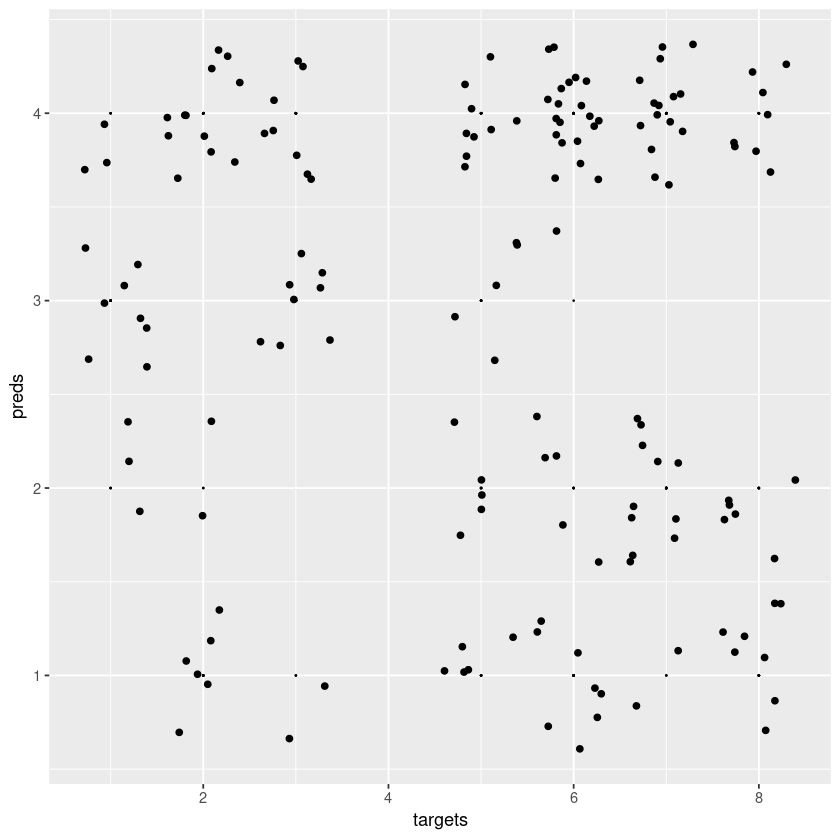

In [25]:
#test_dl <- dataloader(valid_ds, batch_size = 5000)
targets <- (test_dl %>% dataloader_make_iter() %>% dataloader_next())$y %>% as.numeric()

y_pred <- torch_argmax(preds, dim = 2) %>% as.numeric()
df <- data.frame(preds = y_pred, targets = targets)
#library(ggplot2)

print(preds)


ggplot(df, aes(x = targets, y = preds)) +
  geom_point(size = 0.1) +
  geom_jitter()
  theme_classic() +
  xlab("true correlations") +
  ylab("model predictions")

#plot(y_pred, targets)


In [26]:
df$preds %>% as.factor() %>% levels()

[1] "1" "2" "3" "4"

In [27]:
df$targets %>% as.factor() %>% levels()

[1] "1" "2" "3" "5" "6" "7" "8"

In [28]:
target_f <- df$targets %>% as.factor()
levels(target_f) <- c(levels(target_f), '4')

In [29]:
results_cm <- caret::confusionMatrix(
    df$preds %>% as.factor(),
    target_f
)

write(
    rjson::toJSON(results_cm), 
    file = "./linear_results_confusion_indices_only.json"
    )

Warning message in confusionMatrix.default(df$preds %>% as.factor(), target_f):
“Levels are not in the same order for reference and data. Refactoring data to match.”


In [30]:
luz_save(obj = net_fitted,path = "./dl_linear_v2_512.dat")